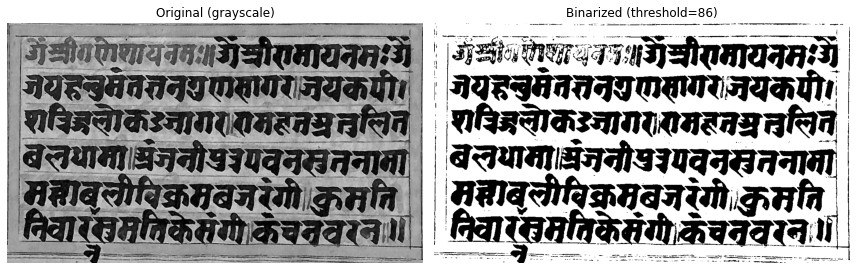

Saved binarized image to: output/binarized_image.jpg (used threshold: 86)


In [1]:
# %%
"""
Convert an image to a binary (binarized) image using Otsu's thresholding.
This notebook-style Python script contains lightweight cells you can paste into a Jupyter .ipynb or run as a .py with an editor that understands "# %%" cells.

Features:
- Read image (grayscale)
- Compute Otsu threshold
- Optional threshold adjustment using image mean intensity (small heuristics)
- Ensure black text on white background
- Show original and binary side-by-side
- Save binary output

Dependencies: opencv-python, numpy, matplotlib, pillow
Install (if needed):
    pip install opencv-python numpy matplotlib pillow
"""

# %%
# Imports
import os
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# %%
# Binarization function using Otsu with optional heuristics

def binarize_image_otsu(image_path, adjust_with_mean=True, save_path=None, show=True):
    """
    Read image at image_path (anything cv2.imread supports), convert to grayscale if needed,
    apply Otsu thresholding and a small heuristic adjustment based on mean intensity,
    ensure result has black text (0) on white background (255), optionally save and show.

    Returns: binary_image (uint8, values 0 or 255), used_threshold (int)
    """
    image_path = str(image_path)
    img = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
    if img is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")

    # If colored, convert to grayscale
    if img.ndim == 3:
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        img_gray = img.copy()

    # If nearly binary already, skip Otsu but still normalize
    unique_vals = np.unique(img_gray)
    if unique_vals.size <= 2:
        # Already binary-like, ensure 0/255 scale
        bin_img = (img_gray > 128).astype(np.uint8) * 255
        used_thresh = None
    else:
        # Compute Otsu
        otsu_thresh, _ = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        # Optional small adjustment based on mean intensity (heuristic)
        used_thresh = int(otsu_thresh)
        if adjust_with_mean:
            mean_intensity = float(np.mean(img_gray))
            if mean_intensity > 200:
                used_thresh = min(used_thresh + 20, 240)
            elif mean_intensity > 150:
                used_thresh = min(used_thresh + 10, 220)
            else:
                used_thresh = max(used_thresh - 10, 40)

        _, bin_img = cv2.threshold(img_gray, used_thresh, 255, cv2.THRESH_BINARY)

    # Ensure black text on white background: count pixels
    white_pixels = np.sum(bin_img == 255)
    black_pixels = np.sum(bin_img == 0)
    if black_pixels > white_pixels:
        bin_img = cv2.bitwise_not(bin_img)

    # Optionally save
    if save_path:
        save_dir = Path(save_path).parent
        save_dir.mkdir(parents=True, exist_ok=True)
        Image.fromarray(bin_img).save(save_path)

    # Optionally show (original + binary)
    if show:
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
        axes[0].imshow(img_gray, cmap='gray', vmin=0, vmax=255)
        axes[0].set_title('Original (grayscale)')
        axes[0].axis('off')

        axes[1].imshow(bin_img, cmap='gray', vmin=0, vmax=255)
        axes[1].set_title(f'Binarized (threshold={used_thresh})')
        axes[1].axis('off')
        plt.tight_layout()
        plt.show()

    return bin_img, used_thresh

# %%
# Example usage cell
if __name__ == '__main__':
    # Replace this with your image path when running the notebook
    sample_image = '../manuscript_dataset/Archive_Org/Hanuman_Chalisa/page_level/images/page_4.png'
    out_path = 'output/binarized_image.jpg'

    # Create output folder
    Path(out_path).parent.mkdir(parents=True, exist_ok=True)

    try:
        bin_img, thresh = binarize_image_otsu(sample_image, adjust_with_mean=True, save_path=out_path, show=True)
        print(f"Saved binarized image to: {out_path} (used threshold: {thresh})")
    except FileNotFoundError as e:
        print(e)

# %%
# Small utility: load and display a saved binary

def display_image(path):
    img = Image.open(path).convert('L')
    plt.figure(figsize=(6,6))
    plt.imshow(np.array(img), cmap='gray', vmin=0, vmax=255)
    plt.axis('off')
    plt.show()

# End of notebook-style script


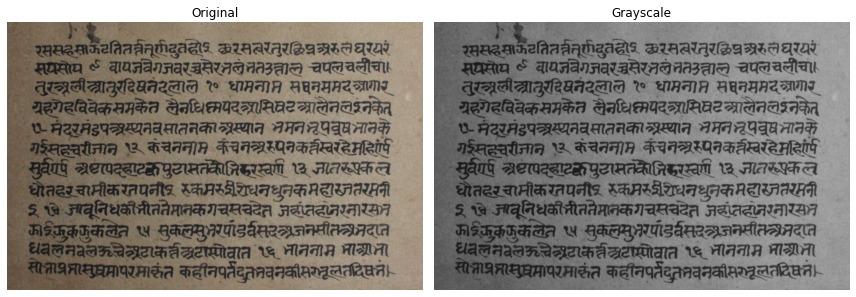

Saved grayscale image to: output/grayscale_image.jpg
Image shape: (912, 1418), dtype: uint8
Intensity range: 20 - 185


In [2]:
# %%
"""
Convert an image to grayscale.
This notebook-style Python script contains lightweight cells you can paste into a Jupyter .ipynb or run as a .py with an editor that understands "# %%" cells.

Features:
- Read image (any format)
- Convert to grayscale
- Optional contrast enhancement using histogram equalization
- Show original and grayscale side-by-side
- Save grayscale output

Dependencies: opencv-python, numpy, matplotlib, pillow
Install (if needed):
    pip install opencv-python numpy matplotlib pillow
"""

# %%
# Imports
import os
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# %%
# Grayscale conversion function with optional enhancement

def convert_to_grayscale(image_path, enhance_contrast=False, save_path=None, show=True):
    """
    Read image at image_path (anything cv2.imread supports), convert to grayscale,
    optionally apply histogram equalization for contrast enhancement,
    optionally save and show.

    Args:
        image_path: Path to input image
        enhance_contrast: If True, apply histogram equalization to improve contrast
        save_path: Optional path to save the grayscale image
        show: If True, display original and grayscale images side-by-side

    Returns: grayscale_image (uint8, values 0-255)
    """
    image_path = str(image_path)
    img = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
    if img is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")

    # Convert to grayscale if needed
    if img.ndim == 3:
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        img_gray = img.copy()

    # Optional contrast enhancement using histogram equalization
    if enhance_contrast:
        img_gray = cv2.equalizeHist(img_gray)

    # Optionally save
    if save_path:
        save_dir = Path(save_path).parent
        save_dir.mkdir(parents=True, exist_ok=True)
        Image.fromarray(img_gray).save(save_path)

    # Optionally show (original + grayscale)
    if show:
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
        
        # Show original (handle both color and grayscale inputs)
        if img.ndim == 3:
            # Convert BGR to RGB for display
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[0].imshow(img_rgb)
        else:
            axes[0].imshow(img, cmap='gray', vmin=0, vmax=255)
        axes[0].set_title('Original')
        axes[0].axis('off')

        # Show grayscale result
        axes[1].imshow(img_gray, cmap='gray', vmin=0, vmax=255)
        title = 'Grayscale (Enhanced)' if enhance_contrast else 'Grayscale'
        axes[1].set_title(title)
        axes[1].axis('off')
        plt.tight_layout()
        plt.show()

    return img_gray

# %%
# Example usage cell
if __name__ == '__main__':
    # Replace this with your image path when running the notebook
    sample_image = '../manuscript_dataset/Archive_Org/maanmanjari/page_level/page_level_images/page_2.png'
    out_path = 'output/grayscale_image.jpg'

    # Create output folder
    Path(out_path).parent.mkdir(parents=True, exist_ok=True)

    try:
        gray_img = convert_to_grayscale(
            sample_image, 
            enhance_contrast=False,  # Set to True for contrast enhancement
            save_path=out_path, 
            show=True
        )
        print(f"Saved grayscale image to: {out_path}")
        print(f"Image shape: {gray_img.shape}, dtype: {gray_img.dtype}")
        print(f"Intensity range: {gray_img.min()} - {gray_img.max()}")
    except FileNotFoundError as e:
        print(e)

# %%
# Small utility: load and display a saved grayscale image

def display_image(path):
    img = Image.open(path).convert('L')
    plt.figure(figsize=(6, 6))
    plt.imshow(np.array(img), cmap='gray', vmin=0, vmax=255)
    plt.title('Grayscale Image')
    plt.axis('off')
    plt.show()

# %%
# Batch conversion utility

def batch_convert_to_grayscale(input_dir, output_dir, enhance_contrast=False):
    """
    Convert all images in input_dir to grayscale and save to output_dir.
    
    Args:
        input_dir: Directory containing input images
        output_dir: Directory to save grayscale images
        enhance_contrast: If True, apply histogram equalization
    """
    input_path = Path(input_dir)
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)
    
    # Supported image extensions
    extensions = ['.png', '.jpg', '.jpeg', '.bmp', '.tiff', '.tif']
    
    image_files = [f for f in input_path.iterdir() 
                   if f.suffix.lower() in extensions]
    
    print(f"Found {len(image_files)} images to convert")
    
    for img_file in image_files:
        try:
            output_file = output_path / img_file.name
            convert_to_grayscale(
                img_file, 
                enhance_contrast=enhance_contrast,
                save_path=output_file, 
                show=False
            )
            print(f"Converted: {img_file.name}")
        except Exception as e:
            print(f"Error converting {img_file.name}: {e}")
    
    print(f"Batch conversion complete! Output saved to: {output_dir}")

# End of notebook-style script


In [3]:
import os
import re
import glob
import cv2
import numpy as np
from PIL import Image
from pathlib import Path


def natural_sort_key(filename):
    """Sort filenames naturally (e.g., page_1, page_2, ..., page_10)"""
    return [int(text) if text.isdigit() else text.lower() for text in re.split(r'(\d+)', filename)]


def add_noise_to_image(img, noise_type='gaussian', noise_amount=50):
    """
    Add noise to a grayscale image.
    
    Args:
        img: Input grayscale image (numpy array)
        noise_type: Type of noise - 'gaussian', 'salt_pepper', or 'speckle'
        noise_amount: Amount of noise (0-100)
    
    Returns: Noisy image
    """
    img_noisy = img.astype(np.float32)
    
    if noise_type == 'gaussian':
        # Gaussian noise
        mean = 0
        sigma = noise_amount
        gauss = np.random.normal(mean, sigma, img.shape)
        img_noisy = img_noisy + gauss
        
    elif noise_type == 'salt_pepper':
        # Salt and pepper noise
        prob = noise_amount / 100.0
        random_matrix = np.random.rand(*img.shape)
        img_noisy[random_matrix < prob/2] = 0  # Pepper
        img_noisy[random_matrix > 1 - prob/2] = 255  # Salt
        
    elif noise_type == 'speckle':
        # Speckle noise
        gauss = np.random.randn(*img.shape)
        img_noisy = img_noisy + img_noisy * gauss * (noise_amount / 100.0)
    
    # Clip values to valid range
    img_noisy = np.clip(img_noisy, 0, 255)
    return img_noisy.astype(np.uint8)


def convert_image_to_grayscale(image_path, output_folder, enhance_contrast=False, 
                                add_noise=True, noise_type='gaussian', noise_amount=500):
    """
    Convert a single image to grayscale and optionally add noise.
    
    Args:
        image_path: Path to input image
        output_folder: Directory to save grayscale image
        enhance_contrast: If True, apply histogram equalization
        add_noise: If True, add noise to the image
        noise_type: Type of noise - 'gaussian', 'salt_pepper', or 'speckle'
        noise_amount: Amount of noise (0-100)
    
    Returns: True if successful, False otherwise
    """
    try:
        # Read the image
        img = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
        if img is None:
            print(f"Error: Could not load image from {image_path}")
            return False
        
        # Convert to grayscale if needed
        if img.ndim == 3:
            img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        else:
            img_gray = img.copy()
        
        # Optional contrast enhancement
        if enhance_contrast:
            img_gray = cv2.equalizeHist(img_gray)
        
        # Add noise if requested
        if add_noise:
            img_gray = add_noise_to_image(img_gray, noise_type, noise_amount)
        
        # Prepare output path with same filename
        filename = os.path.basename(image_path)
        # Change extension to .jpg for consistency
        name_without_ext = os.path.splitext(filename)[0]
        output_filename = f"{name_without_ext}.jpg"
        output_path = os.path.join(output_folder, output_filename)
        
        # Save grayscale image
        Image.fromarray(img_gray).save(output_path, format="JPEG", quality=95)
        
        print(f"✓ Converted: {filename} → {output_filename}")
        return True
        
    except Exception as e:
        print(f"✗ Error processing {os.path.basename(image_path)}: {e}")
        return False


def process_folder(image_folder, output_folder='grayscale_images', enhance_contrast=False,
                   add_noise=True, noise_type='salt_pepper', noise_amount=50):
    """
    Process all images in folder and convert them to grayscale with optional noise.
    
    Args:
        image_folder: Directory containing input images
        output_folder: Directory to save grayscale images
        enhance_contrast: If True, apply histogram equalization for better contrast
        add_noise: If True, add noise to images
        noise_type: Type of noise - 'gaussian' (default), 'salt_pepper', or 'speckle'
        noise_amount: Amount of noise (0-100, default=25)
    """
    # Create output folder if it doesn't exist
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
        print(f"Created output folder: {output_folder}")
    
    # Collect image files
    exts = ['*.png', '*.jpg', '*.jpeg', '*.bmp', '*.tiff', '*.tif']
    image_files = []
    for ext in exts:
        image_files.extend(glob.glob(os.path.join(image_folder, ext)))
        image_files.extend(glob.glob(os.path.join(image_folder, ext.upper())))
    
    if not image_files:
        print(f"No images found in {image_folder}")
        return
    
    # Sort files naturally
    image_files.sort(key=lambda x: natural_sort_key(os.path.basename(x)))
    print(f"\nFound {len(image_files)} images to process")
    print(f"Output folder: {output_folder}")
    print(f"Contrast enhancement: {'ON' if enhance_contrast else 'OFF'}")
    print(f"Noise addition: {'ON' if add_noise else 'OFF'}")
    if add_noise:
        print(f"  - Noise type: {noise_type}")
        print(f"  - Noise amount: {noise_amount}")
    print()
    
    # Process each image
    success_count = 0
    for i, image_path in enumerate(image_files, 1):
        print(f"[{i}/{len(image_files)}] ", end="")
        if convert_image_to_grayscale(image_path, output_folder, enhance_contrast, 
                                     add_noise, noise_type, noise_amount):
            success_count += 1
    
    # Summary
    print(f"\n{'='*60}")
    print(f"✅ Processing complete!")
    print(f"   Successfully converted: {success_count}/{len(image_files)} images")
    print(f"   Output saved to: {output_folder}")
    print(f"{'='*60}")


# Example usage
if __name__ == '__main__':
    # Configuration
    input_folder = '../manuscript_dataset/Archive_Org/maanmanjari/page_level/page_level_images/page_2.png'
    output_folder = 'grayscale_output'
    
    # Run conversion with noise
    process_folder(
        image_folder=input_folder,
        output_folder=output_folder,
        enhance_contrast=False,  # Set to True for contrast enhancement
        add_noise=True,          # Set to False to disable noise
        noise_type='gaussian',   # Options: 'gaussian', 'salt_pepper', 'speckle'
        noise_amount=25          # Noise level (0-100): higher = more noisy
    )


No images found in ../manuscript_dataset/Archive_Org/maanmanjari/page_level/page_level_images/page_2.png
